In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('delivery.csv')
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [3]:
df.columns

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')

In [4]:
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,499.832850,250.791800,2.991110,268.925734,37.520110,30.119015,31.063065,30.119060,31.062971,30.119075,31.062993,2.165303
std,28867.657797,288.255257,144.289418,1.410132,170.490396,10.060876,1.271638,0.487754,1.271674,0.487811,1.271699,0.487826,1.038473
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.000000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25000.750000,250.000000,126.000000,2.000000,129.430000,30.000000,30.023110,31.008774,30.023370,31.008460,30.023295,31.008410,1.355602
50%,50000.500000,499.000000,251.000000,3.000000,233.200000,38.000000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75000.250000,750.000000,376.000000,4.000000,381.510000,45.000000,31.026912,31.371676,31.027112,31.371856,31.027241,31.371508,2.924525
max,100000.000000,1000.000000,500.000000,5.000000,750.000000,60.000000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

In [6]:
X = df.drop(columns = ['Order_ID','User_ID','Driver_ID','Order_Time','Delivery_Time','Restaurant_Lat','Restaurant_Lon','Customer_Lat','Customer_Lon','Driver_Lat','Driver_Lon','Order_Status'])
y = df['Order_Status']

In [7]:
X.isnull().sum()

Restaurant_ID                0
Item_Name                    0
Quantity                     0
Total_Price                  0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Driver_Vehicle               0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Restaurant_ID              100000 non-null  int64  
 1   Item_Name                  100000 non-null  object 
 2   Quantity                   100000 non-null  int64  
 3   Total_Price                100000 non-null  float64
 4   Delivery_Duration_Minutes  100000 non-null  int64  
 5   City                       100000 non-null  object 
 6   Payment_Method             100000 non-null  object 
 7   Driver_Vehicle             100000 non-null  object 
 8   Delivery_Distance_km       100000 non-null  float64
 9   Traffic_Level              100000 non-null  object 
 10  Driver_Availability        100000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 8.4+ MB


In [9]:
X['Driver_Availability'].unique()

array(['Offline', 'Online'], dtype=object)

In [10]:
X.duplicated().sum()

np.int64(0)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant_ID'),
  Text(1, 0, 'Quantity'),
  Text(2, 0, 'Total_Price'),
  Text(3, 0, 'Delivery_Duration_Minutes'),
  Text(4, 0, 'Delivery_Distance_km')])

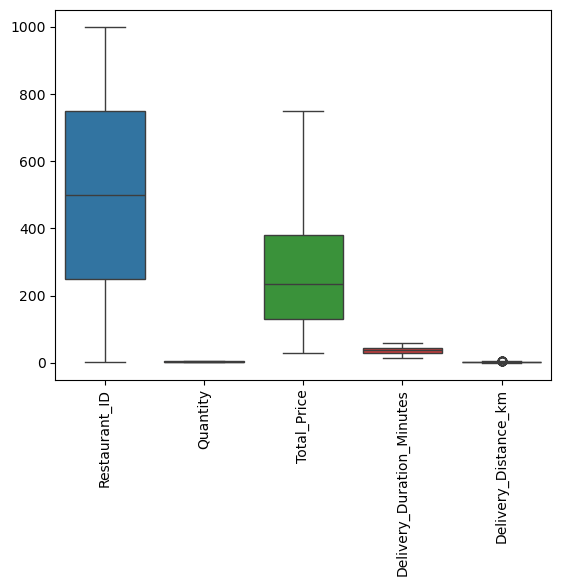

In [11]:
sns.boxplot(X)
plt.xticks(rotation = 90)

In [12]:
Q1 = df['Delivery_Distance_km'].quantile(0.25)
Q3 = df['Delivery_Distance_km'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['Delivery_Distance_km'] >= lower) & (df['Delivery_Distance_km'] <= upper)]
df['Delivery_Distance_km'] = np.where(df['Delivery_Distance_km'] < lower, lower,
              np.where(df['Delivery_Distance_km'] > upper, upper, df['Delivery_Distance_km']))


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant_ID'),
  Text(1, 0, 'Quantity'),
  Text(2, 0, 'Total_Price'),
  Text(3, 0, 'Delivery_Duration_Minutes'),
  Text(4, 0, 'Delivery_Distance_km')])

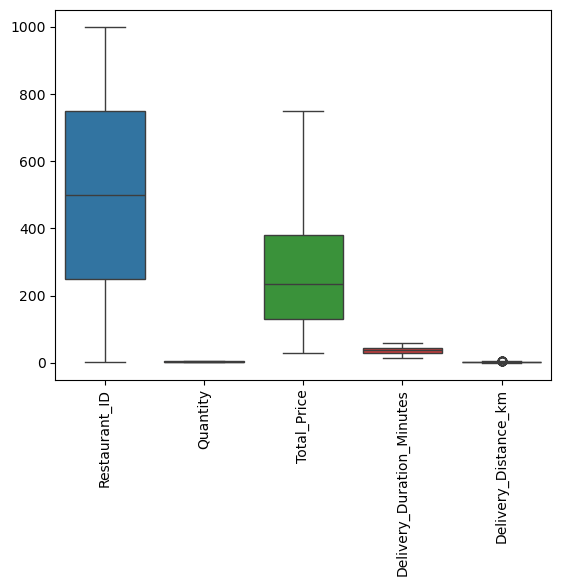

In [13]:
sns.boxplot(X)
plt.xticks(rotation = 90)

In [14]:
X.var

<bound method DataFrame.var of        Restaurant_ID      Item_Name  Quantity  Total_Price  \
0                358  Fried Chicken         3       273.72   
1                316       Sandwich         3       365.82   
2                357        Koshary         3       401.94   
3                420          Sushi         2       221.18   
4                 73        Koshary         5       355.55   
...              ...            ...       ...          ...   
99995            524          Sushi         2        76.54   
99996            459       Shawarma         2        86.50   
99997             12  Fried Chicken         4       165.60   
99998            570        Koshary         4       199.84   
99999            790        Koshary         5       235.30   

       Delivery_Duration_Minutes        City Payment_Method Driver_Vehicle  \
0                             39  Alexandria         Wallet      Motorbike   
1                             33     Zagazig    Credit Card      Mot

In [15]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Restaurant_ID              100000 non-null  int64  
 1   Item_Name                  100000 non-null  object 
 2   Quantity                   100000 non-null  int64  
 3   Total_Price                100000 non-null  float64
 4   Delivery_Duration_Minutes  100000 non-null  int64  
 5   City                       100000 non-null  object 
 6   Payment_Method             100000 non-null  object 
 7   Driver_Vehicle             100000 non-null  object 
 8   Delivery_Distance_km       100000 non-null  float64
 9   Traffic_Level              100000 non-null  object 
 10  Driver_Availability        100000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 8.4+ MB


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 11)
(20000, 11)
(80000,)
(20000,)


In [18]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer(transformers=[('t1',OrdinalEncoder(),cat_cols),
                                            ('t2',StandardScaler(),num_cols)])
# Let us apply fit_transform on Train Data
X_train_trans=transformer.fit_transform(X_train)
# Let us apply transform on test data
X_test_trans=transformer.transform(X_test)

In [19]:
X_train_trans=pd.DataFrame(X_train_trans)
X_train_trans.head()

,0,1,2,3,4,5,6,7,8,9,10
0,5.0,3.0,1.0,0.0,2.0,1.0,-1.008601,0.717122,0.214529,0.843565,-0.261589
1,0.0,0.0,1.0,1.0,2.0,1.0,0.774928,-1.410810,-1.358038,1.539091,1.258272
2,0.0,3.0,0.0,0.0,1.0,1.0,1.517487,0.717122,-0.796445,1.241009,-0.569622
3,0.0,4.0,0.0,1.0,0.0,1.0,-1.706051,0.007811,-0.888683,-1.044291,1.286745
4,0.0,1.0,2.0,1.0,1.0,1.0,-1.223735,1.426433,0.447473,-0.150044,0.473010


In [20]:
X_test_trans=pd.DataFrame(X_test_trans)
X_test_trans.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1.0,3.0,2.0,1.0,2.0,0.0,0.709000,-0.701499,-0.157125,0.744204,0.223800
1,7.0,0.0,2.0,0.0,1.0,1.0,-0.477706,0.007811,-0.702386,-0.249404,0.422256
2,1.0,0.0,1.0,1.0,1.0,1.0,1.000472,0.007811,-0.416684,1.638452,0.701530
3,0.0,4.0,0.0,0.0,0.0,1.0,-0.991252,0.717122,-0.825585,-0.050683,-1.463637
4,4.0,0.0,0.0,2.0,1.0,1.0,-0.869805,0.717122,-0.298713,-0.249404,-0.404118


# KNN

In [21]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_trans,y_train)

KNeighborsClassifier()

In [22]:
y_train_trans=knn.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of knn:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of knn:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of knn:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of knn:',f1)

acc Score of knn: 0.8558
classification report Score of knn:
              precision    recall  f1-score   support

   Cancelled       0.09      0.48      0.16      1516
   Delivered       0.99      0.86      0.92     78385
  In Transit       0.02      0.71      0.03        99

    accuracy                           0.86     80000
   macro avg       0.37      0.68      0.37     80000
weighted avg       0.97      0.86      0.91     80000

confusion metrix Score of knn:
[[  727   580   209]
 [ 7079 67667  3639]
 [    1    28    70]]
f1 Score of knn: 0.907143807663589


In [23]:
y_pred = knn.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [24]:
y_pred=knn.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of knn:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of knn:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of knn:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of knn:',f1)

acc Score of knn: 0.83205
classification report Score of knn:
              precision    recall  f1-score   support

   Cancelled       0.02      0.12      0.04       378
   Delivered       0.98      0.85      0.91     19595
  In Transit       0.00      0.15      0.01        27

    accuracy                           0.83     20000
   macro avg       0.34      0.37      0.32     20000
weighted avg       0.96      0.83      0.89     20000

confusion metrix Score of knn:
[[   46   309    23]
 [ 1958 16591  1046]
 [    1    22     4]]
f1 Score of knn: 0.891011538040254


# Naive Bayes

In [25]:
from sklearn.naive_bayes import GaussianNB
ng=GaussianNB()
ng.fit(X_train_trans,y_train)

GaussianNB()

In [26]:
y_train_trans=ng.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Naive:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Naive:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Naive:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Naive:',f1)

acc Score of Naive: 0.8534375
classification report Score of Naive:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         0
   Delivered       1.00      0.85      0.92     80000
  In Transit       0.00      0.00      0.00         0

    accuracy                           0.85     80000
   macro avg       0.33      0.28      0.31     80000
weighted avg       1.00      0.85      0.92     80000

confusion metrix Score of Naive:
[[    0     0     0]
 [ 7807 68275  3918]
 [    0     0     0]]
f1 Score of Naive: 0.9209239588602258


In [27]:
y_pred = ng.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [28]:
y_pred=ng.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Naive:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Naive:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Naive:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Naive:',f1)

acc Score of Naive: 0.8461
classification report Score of Naive:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         0
   Delivered       1.00      0.85      0.92     20000
  In Transit       0.00      0.00      0.00         0

    accuracy                           0.85     20000
   macro avg       0.33      0.28      0.31     20000
weighted avg       1.00      0.85      0.92     20000

confusion metrix Score of Naive:
[[    0     0     0]
 [ 2005 16922  1073]
 [    0     0     0]]
f1 Score of Naive: 0.9166350685228319


# Decision Tree

In [29]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini',random_state=42)
model.fit(X_train_trans,y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
y_train_trans=model.predict(X_train_trans)

In [31]:
y_train_trans=model.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Tree:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Tree:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Tree:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Tree:',f1)

acc Score of Tree: 1.0
classification report Score of Tree:
              precision    recall  f1-score   support

   Cancelled       1.00      1.00      1.00      7807
   Delivered       1.00      1.00      1.00     68275
  In Transit       1.00      1.00      1.00      3918

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000

confusion metrix Score of Tree:
[[ 7807     0     0]
 [    0 68275     0]
 [    0     0  3918]]
f1 Score of Tree: 1.0


In [32]:
y_pred = model.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [33]:
y_pred=model.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Tree:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Tree:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Tree:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Tree:',f1)

acc Score of Tree: 0.70605
classification report Score of Tree:
              precision    recall  f1-score   support

   Cancelled       0.11      0.09      0.10      2327
   Delivered       0.82      0.84      0.83     16418
  In Transit       0.06      0.05      0.05      1255

    accuracy                           0.71     20000
   macro avg       0.33      0.33      0.33     20000
weighted avg       0.69      0.71      0.70     20000

confusion metrix Score of Tree:
[[  211  2007   109]
 [ 1666 13849   903]
 [  128  1066    61]]
f1 Score of Tree: 0.6966048820095619


# Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=1000,)
LR.fit(X_train_trans, y_train)

LogisticRegression(max_iter=1000)

In [35]:
y_train_trans=LR.predict(X_train_trans)

In [36]:
y_train_trans=LR.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Logistic:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Logistic:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Logistic:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Logistic:',f1)

acc Score of Logistic: 0.8534375
classification report Score of Logistic:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         0
   Delivered       1.00      0.85      0.92     80000
  In Transit       0.00      0.00      0.00         0

    accuracy                           0.85     80000
   macro avg       0.33      0.28      0.31     80000
weighted avg       1.00      0.85      0.92     80000

confusion metrix Score of Logistic:
[[    0     0     0]
 [ 7807 68275  3918]
 [    0     0     0]]
f1 Score of Logistic: 0.9209239588602258


In [37]:
y_pred = LR.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [38]:
y_pred=LR.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Logistic:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Logistic:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Logistic:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Logistic:',f1)

acc Score of Logistic: 0.8461
classification report Score of Logistic:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         0
   Delivered       1.00      0.85      0.92     20000
  In Transit       0.00      0.00      0.00         0

    accuracy                           0.85     20000
   macro avg       0.33      0.28      0.31     20000
weighted avg       1.00      0.85      0.92     20000

confusion metrix Score of Logistic:
[[    0     0     0]
 [ 2005 16922  1073]
 [    0     0     0]]
f1 Score of Logistic: 0.9166350685228319


In [39]:
import pickle

with open("Ng_Delivery_pipeline.pkl", "wb") as f:
    pickle.dump(ng, f)
print("Model saved successfully!")

Model saved successfully!


In [40]:
with open("delivery_status_model.pkl", "wb") as f:
    pickle.dump(LR, f)
print('Model saved successfully!')

Model saved successfully!


In [41]:
X['City'].unique()

array(['Alexandria', 'Zagazig', 'Assiut', 'Mansoura', 'Cairo', 'Tanta',
       'Giza'], dtype=object)

In [42]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Restaurant_ID              100000 non-null  int64  
 1   Item_Name                  100000 non-null  object 
 2   Quantity                   100000 non-null  int64  
 3   Total_Price                100000 non-null  float64
 4   Delivery_Duration_Minutes  100000 non-null  int64  
 5   City                       100000 non-null  object 
 6   Payment_Method             100000 non-null  object 
 7   Driver_Vehicle             100000 non-null  object 
 8   Delivery_Distance_km       100000 non-null  float64
 9   Traffic_Level              100000 non-null  object 
 10  Driver_Availability        100000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 8.4+ MB


In [43]:
X['Driver_Vehicle'].unique()

array(['Motorbike', 'Car', 'Bicycle'], dtype=object)

# Ensemble Techniques

# Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
Rdc = RandomForestClassifier(random_state=42)
Rdc.fit(X_train_trans, y_train)

RandomForestClassifier(random_state=42)

In [47]:
y_train_trans=Rdc.predict(X_train_trans)

In [92]:
y_train_trans=Rdc.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of RandomForest:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of RandomForest:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of RandomForest:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of RandomFroest:',f1)

acc Score of RandomForest: 0.9999875
classification report Score of RandomForest:
              precision    recall  f1-score   support

   Cancelled       1.00      1.00      1.00      7807
   Delivered       1.00      1.00      1.00     68276
  In Transit       1.00      1.00      1.00      3917

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000

confusion metrix Score of RandomForest:
[[ 7807     0     0]
 [    0 68275     1]
 [    0     0  3917]]
f1 Score of RandomFroest: 0.9999875007519324


In [93]:
y_pred = Rdc.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [94]:
y_pred=Rdc.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of RandomForest:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of RandomForest:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of RandomForest:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of RandomForest:',f1)

acc Score of RandomForest: 0.8461
classification report Score of RandomForest:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         0
   Delivered       1.00      0.85      0.92     20000
  In Transit       0.00      0.00      0.00         0

    accuracy                           0.85     20000
   macro avg       0.33      0.28      0.31     20000
weighted avg       1.00      0.85      0.92     20000

confusion metrix Score of RandomForest:
[[    0     0     0]
 [ 2005 16922  1073]
 [    0     0     0]]
f1 Score of RandomForest: 0.9166350685228319


# Bagging Classifier

In [52]:
from sklearn.ensemble import BaggingClassifier

In [54]:
Bgc = BaggingClassifier(estimator=model,n_estimators=50,random_state=42)
Bgc.fit(X_train_trans,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, random_state=42)

In [88]:
y_train_trans=Bgc.predict(X_train_trans)

In [89]:
y_train_trans=Bgc.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Bagging:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Bagging:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Bagging:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Bagging:',f1)

acc Score of Bagging: 0.999525
classification report Score of Bagging:
              precision    recall  f1-score   support

   Cancelled       1.00      1.00      1.00      7787
   Delivered       1.00      1.00      1.00     68313
  In Transit       1.00      1.00      1.00      3900

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000

confusion metrix Score of Bagging:
[[ 7787     0     0]
 [   20 68275    18]
 [    0     0  3900]]
f1 Score of Bagging: 0.9995253532611041


In [90]:
y_pred = Bgc.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [91]:
y_pred=Bgc.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Bagging:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Bagging:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Bagging:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Bagging:',f1)

acc Score of Bagging: 0.8459
classification report Score of Bagging:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         5
   Delivered       1.00      0.85      0.92     19995
  In Transit       0.00      0.00      0.00         0

    accuracy                           0.85     20000
   macro avg       0.33      0.28      0.31     20000
weighted avg       1.00      0.85      0.92     20000

confusion metrix Score of Bagging:
[[    0     4     1]
 [ 2005 16918  1072]
 [    0     0     0]]
f1 Score of Bagging: 0.9163133786602379


In [59]:
from sklearn.ensemble import GradientBoostingClassifier

In [60]:
gb_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
gb_model.fit(X_train_trans, y_train)

GradientBoostingClassifier(random_state=42)

In [61]:
y_train_trans=gb_model.predict(X_train_trans)

In [86]:
y_train_trans=gb_model.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Gradient:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Gradient:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Gradient:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Gradient:',f1)

acc Score of Gradient: 0.853675
classification report Score of Gradient:
              precision    recall  f1-score   support

   Cancelled       0.00      1.00      0.00        10
   Delivered       1.00      0.85      0.92     79981
  In Transit       0.00      1.00      0.00         9

    accuracy                           0.85     80000
   macro avg       0.33      0.95      0.31     80000
weighted avg       1.00      0.85      0.92     80000

confusion metrix Score of Gradient:
[[   10     0     0]
 [ 7797 68275  3909]
 [    0     0     9]]
f1 Score of Gradient: 0.920824069443518


In [85]:
y_pred = gb_model.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [82]:
y_pred=gb_model.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Gradient:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Gradient:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Gradient:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Gradient:',f1)

acc Score of Gradient: 0.8459
classification report Score of Gradient:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         1
   Delivered       1.00      0.85      0.92     19996
  In Transit       0.00      0.00      0.00         3

    accuracy                           0.85     20000
   macro avg       0.33      0.28      0.31     20000
weighted avg       1.00      0.85      0.92     20000

confusion metrix Score of Gradient:
[[    0     1     0]
 [ 2005 16918  1073]
 [    0     3     0]]
f1 Score of Gradient: 0.9163343843111761


# Voting Classifier

In [68]:
from sklearn.ensemble import VotingClassifier
import xgboost as xgb

In [70]:
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model),('Rdc', Rdc),('lr', LR)],voting='soft')
voting_model.fit(X_train_trans, y_train)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('Rdc', RandomForestClassifier(random_state=42)),
                             ('lr', LogisticRegression(max_iter=1000))],
                 voting='soft')

In [74]:
y_train_trans=voting_model.predict(X_train_trans)

In [79]:
y_train_trans=voting_model.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Voting:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Voting:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Voting:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Voting:',f1)

acc Score of Voting: 0.85415
classification report Score of Voting:
              precision    recall  f1-score   support

   Cancelled       0.01      1.00      0.01        44
   Delivered       1.00      0.85      0.92     79943
  In Transit       0.00      1.00      0.01        13

    accuracy                           0.85     80000
   macro avg       0.34      0.95      0.31     80000
weighted avg       1.00      0.85      0.92     80000

confusion metrix Score of Voting:
[[   44     0     0]
 [ 7763 68275  3905]
 [    0     0    13]]
f1 Score of Voting: 0.9206289463189345


In [80]:
y_pred = voting_model.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(20000,)
(20000,)


In [81]:
y_pred=voting_model.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Voting:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Voting:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Voting:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Voting:',f1)

acc Score of Voting: 0.8461
classification report Score of Voting:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00         0
   Delivered       1.00      0.85      0.92     20000
  In Transit       0.00      0.00      0.00         0

    accuracy                           0.85     20000
   macro avg       0.33      0.28      0.31     20000
weighted avg       1.00      0.85      0.92     20000

confusion metrix Score of Voting:
[[    0     0     0]
 [ 2005 16922  1073]
 [    0     0     0]]
f1 Score of Voting: 0.9166350685228319


In [96]:
import pickle
from sklearn.metrics import accuracy_score

# all trained models
all_models = {
    'KNN':               knn,
    'Naive Bayes':       ng,
    'Decision Tree':     model,
    'Logistic Reg':      LR,
    'Random Forest':     Rdc,
    'Bagging':           Bgc,
    'Gradient Boosting': gb_model,
    'Voting':            voting_model
}

# find best model by test accuracy
best_name, best_model, best_acc = None, None, 0
for name, m in all_models.items():
    acc = accuracy_score(y_test, m.predict(X_test_trans))
    if acc > best_acc:
        best_acc  = acc
        best_name = name
        best_model = m

print(f"Best Model : {best_name}")
print(f"Accuracy   : {best_acc:.4f}")

# save
pickle.dump(best_model,  open('model.pkl',       'wb'))
pickle.dump(transformer, open('transformer.pkl',  'wb'))
pickle.dump(X.columns,   open('features.pkl',     'wb'))

print("Saved: model.pkl, transformer.pkl, features.pkl")

Best Model : Naive Bayes
Accuracy   : 0.8461
Saved: model.pkl, transformer.pkl, features.pkl


In [97]:
model       = pickle.load(open('model.pkl',      'rb'))
transformer = pickle.load(open('transformer.pkl', 'rb'))
features    = pickle.load(open('features.pkl',    'rb'))